In [2]:
import mne
import matplotlib.pyplot as plt

In [3]:
def edf_to_numpy(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    data, times = raw.get_data(return_times=True)  # data.shape = (n_channels, n_samples)
    return data, times

Extracting EDF parameters from C:\Users\gabri\Documents\GbmsRepositorios\ISB2025-1\Proyecto\Software\eeg-during-mental-arithmetic-tasks\Subject06_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...
Extracting EDF parameters from C:\Users\gabri\Documents\GbmsRepositorios\ISB2025-1\Proyecto\Software\eeg-during-mental-arithmetic-tasks\Subject06_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...


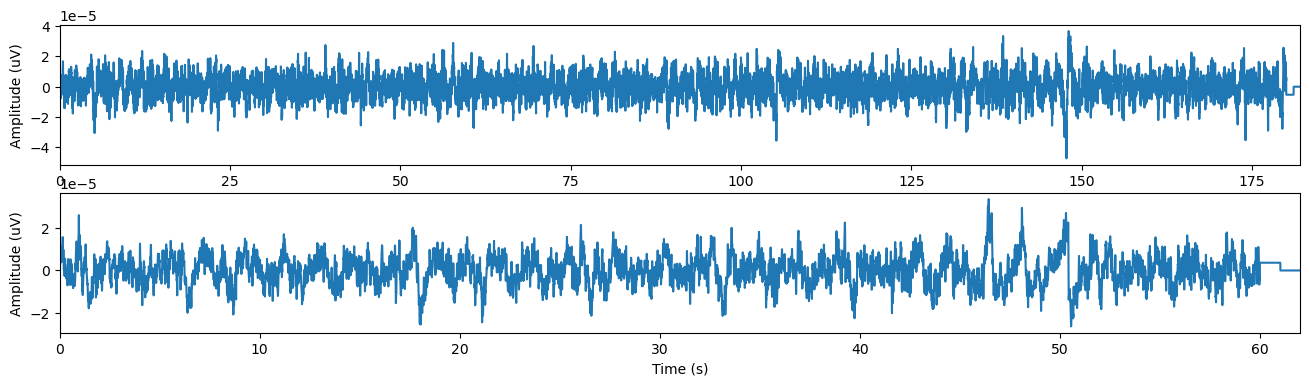

In [10]:
data_before_task, t1 = edf_to_numpy('./eeg-during-mental-arithmetic-tasks/Subject06_1.edf')
data_during_task, t2 = edf_to_numpy('./eeg-during-mental-arithmetic-tasks/Subject06_2.edf')

plt.figure(figsize=(16,4))
plt.subplot(2,1,1);plt.plot(t1,data_before_task[5])
plt.xlabel("Time (s)");plt.ylabel("Amplitude (uV)");plt.xlim([0,182])
plt.subplot(2,1,2);plt.plot(t2,data_during_task[5])
plt.xlabel("Time (s)");plt.ylabel("Amplitude (uV)");plt.xlim([0,62])
plt.show();

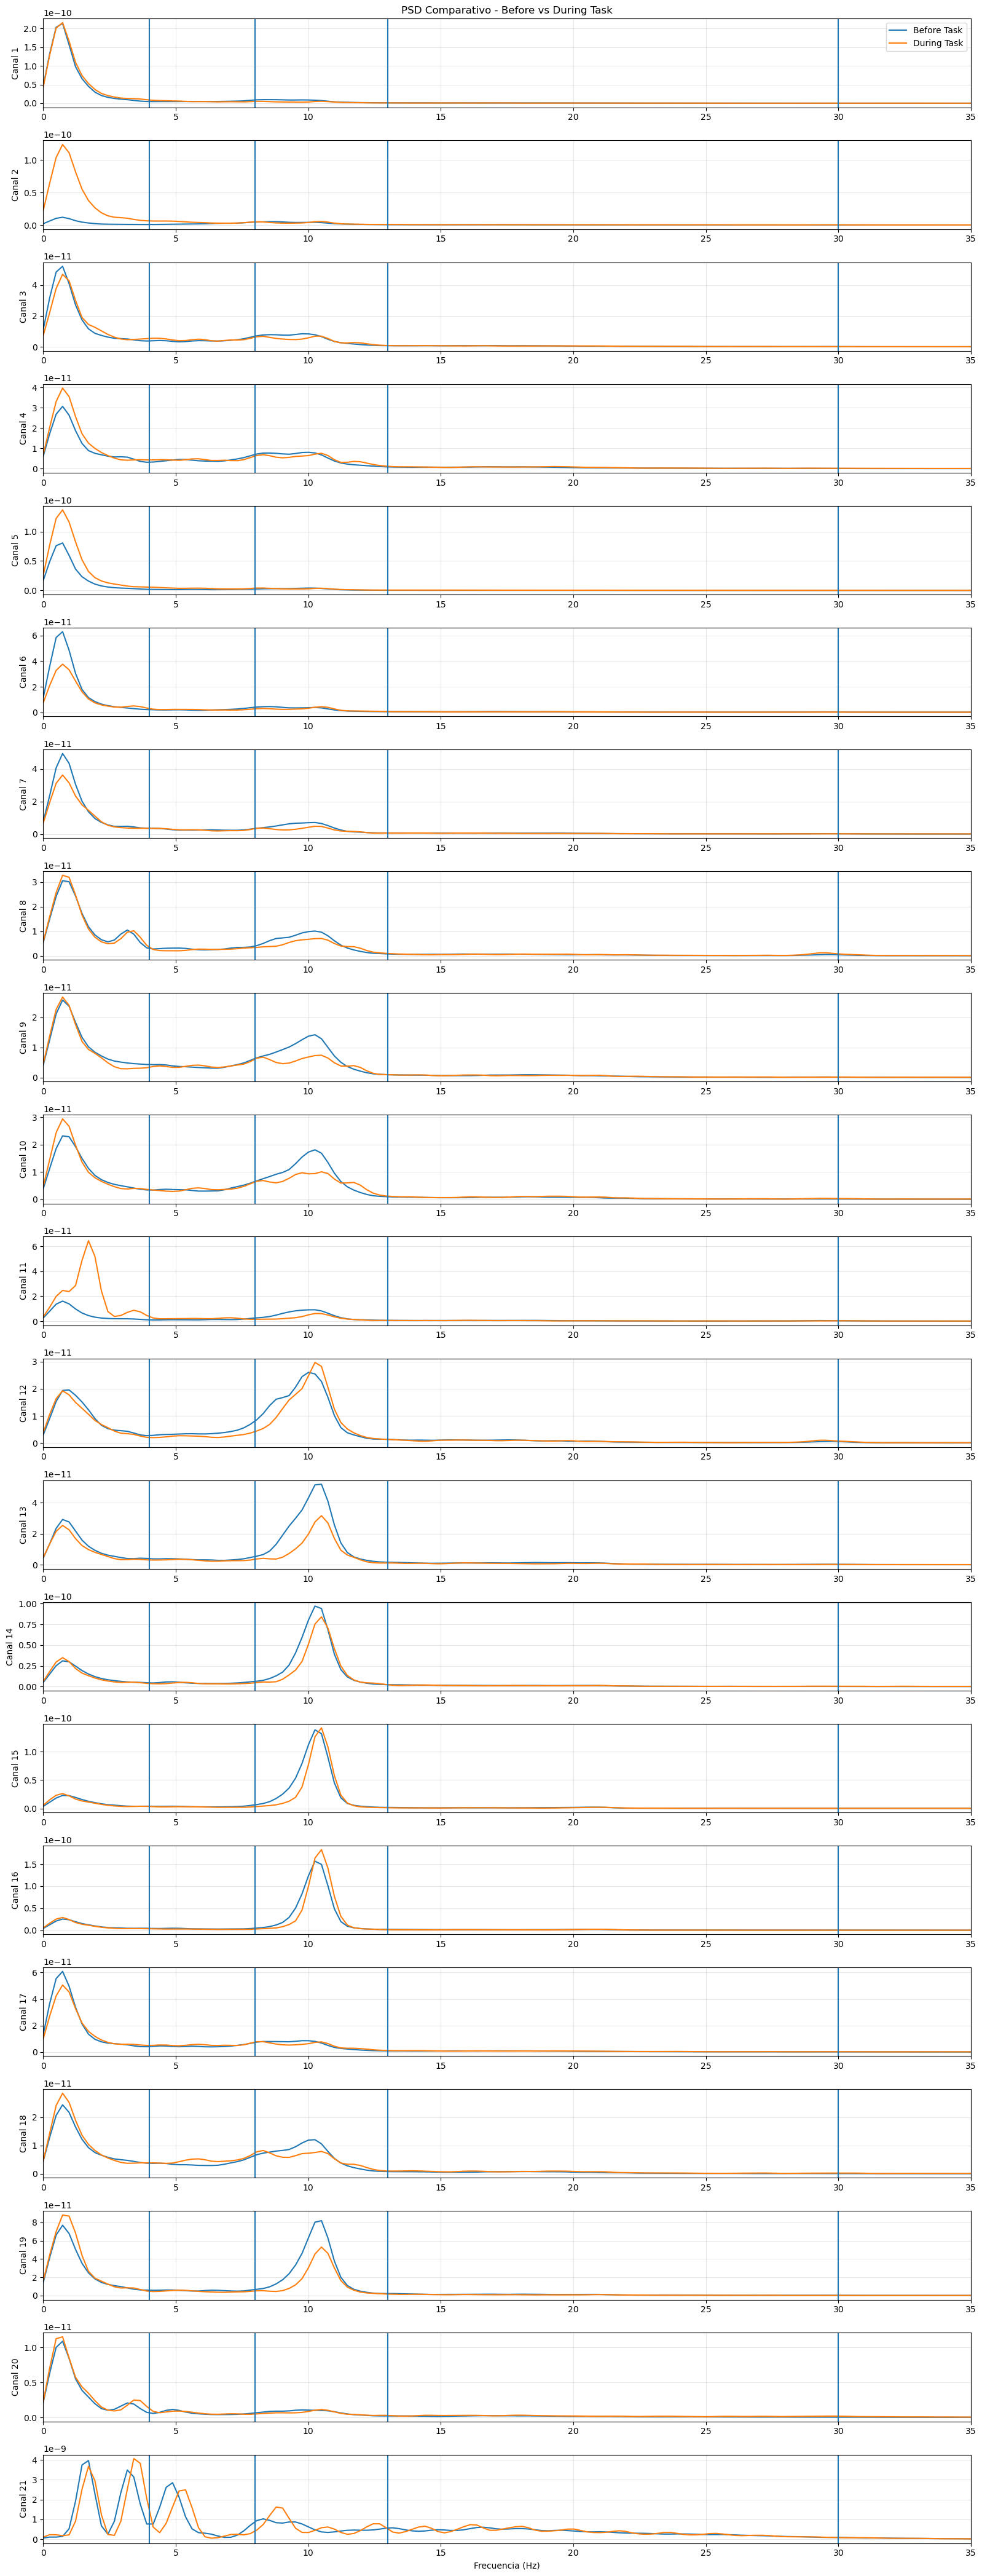

In [9]:
from scipy import signal
freqs1, psd_before_task = signal.welch(data_before_task, fs=500, nperseg=1024, noverlap=512, nfft=2048)
freqs2, psd_during_task = signal.welch(data_during_task, fs=500, nperseg=1024, noverlap=512, nfft=2048)

plt.figure(figsize=(16, 42))

for i in range(21):
    plt.subplot(21, 1, i + 1)
    plt.plot(freqs1, psd_before_task[i], label='Before Task')
    plt.plot(freqs2, psd_during_task[i], label='During Task')
    
    for x in [4, 8, 13, 30]:
        plt.axvline(x=x)
    
    plt.xlim([0,35])
    plt.grid(alpha=0.3)

    if i == 0:
        plt.legend()
        plt.title('PSD Comparativo - Before vs During Task')
    
    plt.ylabel(f'Canal {i + 1}')

plt.xlabel('Frecuencia (Hz)')
plt.tight_layout()
plt.show()